# Vérification des 18 zones : réanalyse ↔ prévision archivée

**Pourquoi ce notebook.** En refaisant la validation temporelle
(`validation_temporelle_prevision.ipynb`), on a vu que `dakar_banlieue_prevruns.csv` porte le nom
`keur_massar`. Or l'article (§III-A) dit que **deux points mal géolocalisés** (Keur Massar et
Kaolack, à plus de 50 km de la vraie ville) ont été corrigés. Question : cette correction a-t-elle
été appliquée **partout**, y compris aux prévisions archivées (*Previous Runs*) utilisées en §V-B ?

Vérifications :
1. coordonnées de chaque source (réanalyse, script de prévision) vs position réelle de la ville ;
2. cohérence des pluies : la pluie « observée » des fichiers de prévision correspond-elle à la
   réanalyse de **la même** zone ?
3. zones redondantes (même cellule météo → pseudo-réplication) ;
4. re-téléchargement des prévisions aux **bonnes** coordonnées si nécessaire.

In [1]:
import ast, re, time
from pathlib import Path
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

ROOT = Path.cwd()
REA_FILES = sorted((ROOT / "donnees").glob("*_2005_2025.csv")) + sorted((ROOT / "donnees_extra").glob("*_2005_2025.csv"))
PR_DIR = ROOT / "donnees_previous_runs"
PR_V2 = ROOT / "donnees_previous_runs_v2"          # prévisions re-téléchargées (corrigées)
OUT = ROOT / "rf_forecast_results" / "verification_zones"
OUT.mkdir(parents=True, exist_ok=True)

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp, dl = p2 - p1, np.radians(lon2 - lon1)
    a = np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

print(len(REA_FILES), "fichiers de réanalyse")

/Users/mac/Documents/Innond/.venv_rf/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


18 fichiers de réanalyse


## 1. Coordonnées : réanalyse, scripts de prévision, ville réelle

In [2]:
# (a) réanalyse : coordonnées de la cellule renvoyées par Open-Meteo (2e ligne du CSV)
rea = []
for f in REA_FILES:
    lat, lon = map(float, f.read_text().splitlines()[1].split(",")[:2])
    rea.append(dict(zone=f.stem.replace("_2005_2025", ""), lat_rea=lat, lon_rea=lon))
rea = pd.DataFrame(rea).set_index("zone")

# (b) coordonnées DEMANDÉES par les scripts de téléchargement des prévisions (dict ZONES)
def zones_of(script):
    src = (ROOT / script).read_text()
    m = re.search(r"ZONES\s*=\s*(\{.*?\n\})", src, re.S)
    return {k: v[:2] for k, v in ast.literal_eval(m.group(1)).items()}
pr_req = {**zones_of("fetch_previous_runs.py"), **zones_of("fetch_previous_runs_extra.py")}
for k, v in pr_req.items():
    print(f"  script prévision : {k:15s} {v}")

# (c) « location » écrite dans chaque fichier de prévision
pr_loc = {c.stem.replace("_prevruns", ""): pd.read_csv(c, nrows=1).location.iloc[0]
          for c in sorted(PR_DIR.glob("*_prevruns.csv"))}

  script prévision : kaolack_leona   (13.813708, -15.551483)
  script prévision : keur_massar     (15.43058, -15.887329)
  script prévision : kolda           (12.899824, -14.959137)
  script prévision : matam           (15.641477, -13.220337)
  script prévision : tambacounda     (13.743409, -13.636383)
  script prévision : touba           (14.86819, -15.852753)
  script prévision : dakar           (14.6928, -17.4467)
  script prévision : saint_louis     (16.0326, -16.4818)
  script prévision : ziguinchor      (12.5641, -16.2719)
  script prévision : diourbel        (14.6561, -16.2314)
  script prévision : thies           (14.791, -16.9256)
  script prévision : fatick          (14.339, -16.411)
  script prévision : louga           (15.6194, -16.2264)
  script prévision : kaffrine        (14.1057, -15.5416)
  script prévision : sedhiou         (12.7081, -15.5569)
  script prévision : kedougou        (12.5556, -12.1747)
  script prévision : bakel           (14.901, -12.4665)
  script prév

In [3]:
# (d) position de référence de la ville (géocodage Open-Meteo, mis en cache)
TOWN = {"bakel": "Bakel", "dakar_banlieue": "Keur Massar", "diourbel": "Diourbel", "fatick": "Fatick",
        "kaffrine": "Kaffrine", "kaolack_leona": "Kaolack", "kedougou": "Kédougou", "kolda": "Kolda",
        "louga": "Louga", "matam": "Matam", "mbacke": "Mbacké", "podor": "Podor",
        "saint_louis": "Saint-Louis", "sedhiou": "Sédhiou", "tambacounda": "Tambacounda",
        "thies": "Thiès", "touba": "Touba", "ziguinchor": "Ziguinchor"}
# région administrative attendue : évite les homonymes (il existe un « Keur Massar » dans la région de Louga !)
REGION = {"bakel": "Tambacounda", "dakar_banlieue": "Dakar", "diourbel": "Diourbel", "fatick": "Fatick",
          "kaffrine": "Kaffrine", "kaolack_leona": "Kaolack", "kedougou": "Kédougou", "kolda": "Kolda",
          "louga": "Louga", "matam": "Matam", "mbacke": "Diourbel", "podor": "Saint-Louis",
          "saint_louis": "Saint-Louis", "sedhiou": "Sédhiou", "tambacounda": "Tambacounda",
          "thies": "Thiès", "touba": "Diourbel", "ziguinchor": "Ziguinchor"}
homonymes = requests.get("https://geocoding-api.open-meteo.com/v1/search",
                         params=dict(name="Keur Massar", count=10, language="fr", countryCode="SN"), timeout=30).json()
print("Homonymes de « Keur Massar » au Sénégal :")
for x in homonymes.get("results", []):
    print(f"   {x['name']:12s} {x['latitude']:.3f}, {x['longitude']:.3f}   région {x.get('admin1')}")
cache = OUT / "geocodage_villes.csv"
if cache.exists():
    town = pd.read_csv(cache, index_col="zone")
else:
    rows_ = []
    for z, name in TOWN.items():
        r = requests.get("https://geocoding-api.open-meteo.com/v1/search",
                         params=dict(name=name, count=5, language="fr", countryCode="SN"), timeout=30).json()
        res = [x for x in r.get("results", []) if x.get("country_code") == "SN" and x.get("admin1") == REGION[z]]
        x = res[0] if res else {}
        rows_.append(dict(zone=z, ville=name, lat_ville=x.get("latitude"), lon_ville=x.get("longitude"),
                          nom_trouvé=x.get("name"), région=x.get("admin1")))
        time.sleep(0.3)
    town = pd.DataFrame(rows_).set_index("zone")
    town.to_csv(cache)
town

Homonymes de « Keur Massar » au Sénégal :
   Keur Massar  15.463, -15.886   région Louga
   Keur Massar  14.780, -17.311   région Dakar
   Keur Massar  13.883, -14.800   région Kaffrine
   Keur Massar Ba 13.667, -15.900   région Kaolack


,ville,lat_ville,lon_ville,nom_trouvé,région
zone,,,,,
bakel,Bakel,14.90238,-12.45935,Bakel,Tambacounda
dakar_banlieue,Keur Massar,14.77977,-17.31131,Keur Massar,Dakar
diourbel,Diourbel,14.64792,-16.24363,Diourbel,Diourbel
fatick,Fatick,14.33236,-16.40513,Fatick,Fatick
kaffrine,Kaffrine,14.10594,-15.55080,Kaffrine,Kaffrine
kaolack_leona,Kaolack,14.15197,-16.07259,Kaolack,Kaolack
kedougou,Kédougou,12.55561,-12.18076,Kédougou,Kédougou
kolda,Kolda,12.89390,-14.94125,Kolda,Kolda
louga,Louga,15.61867,-16.22436,Louga,Louga


In [4]:
# nom du fichier de prévision -> clé dans les scripts (location écrite dans le fichier)
tab = rea.join(town)
tab["location_fichier_prev"] = [pr_loc.get(z) for z in tab.index]
tab["lat_prev"] = [pr_req.get(pr_loc.get(z), (np.nan, np.nan))[0] for z in tab.index]
tab["lon_prev"] = [pr_req.get(pr_loc.get(z), (np.nan, np.nan))[1] for z in tab.index]
tab["km_rea_ville"] = haversine(tab.lat_rea, tab.lon_rea, tab.lat_ville, tab.lon_ville).round(1)
tab["km_script_ville"] = haversine(tab.lat_prev, tab.lon_prev, tab.lat_ville, tab.lon_ville).round(1)
tab["km_script_rea"] = haversine(tab.lat_prev, tab.lon_prev, tab.lat_rea, tab.lon_rea).round(1)
tab["script"] = np.where(tab.km_script_ville > 20, "⚠️ coordonnées obsolètes dans le script", "ok")
tab.to_csv(OUT / "coordonnees_zones.csv")
tab[["ville", "location_fichier_prev", "km_rea_ville", "km_script_ville", "km_script_rea", "script"]]

,ville,location_fichier_prev,km_rea_ville,km_script_ville,km_script_rea,script
zone,,,,,,
kolda,Kolda,kolda,2.0,2.0,0.0,ok
matam,Matam,matam,4.1,4.1,0.0,ok
tambacounda,Tambacounda,tambacounda,4.5,4.5,0.0,ok
touba,Touba,touba,2.5,2.5,0.0,ok
bakel,Bakel,bakel,5.6,0.8,5.0,ok
dakar_banlieue,Keur Massar,keur_massar,4.3,169.1,171.7,⚠️ coordonnées obsolètes dans le script
diourbel,Diourbel,diourbel,2.1,1.6,0.5,ok
fatick,Fatick,fatick,3.0,1.0,3.8,ok
kaffrine,Kaffrine,kaffrine,3.0,1.0,2.1,ok


→ `km_script_*` = coordonnées **écrites dans les scripts** de téléchargement ; rien ne prouve que
les fichiers présents sur disque aient été produits avec ces coordonnées (les fichiers ne les
stockent pas). La section 2 le vérifie par les données. La grille ERA5 fait ~25 km (Open-Meteo interpole à ~11 km) : quelques km d'écart entre
cellule et centre-ville sont normaux. Un écart de **plusieurs dizaines de km** signifie que la
prévision ne porte pas sur la zone.

## 2. Test par la pluie : chaque fichier de prévision ressemble-t-il à SA zone ?

Chaque fichier de prévision contient aussi la pluie « observée » (`actual`, analyse du modèle de
prévision). On la corrèle avec la pluie de réanalyse de **chacune** des 18 zones
(saisons des pluies 2024–2025). Si la zone la plus corrélée n'est pas la zone attendue, le
fichier est mal placé.

In [5]:
def rea_daily_precip(f):
    h = pd.read_csv(f, skiprows=3)
    h.columns = [c.split(" (")[0] for c in h.columns]
    h["time"] = pd.to_datetime(h["time"], errors="coerce")
    h = h.dropna(subset=["time"])
    d = h.groupby(h.time.dt.floor("D"))["precipitation"].sum()
    return d

REA_P = pd.DataFrame({f.stem.replace("_2005_2025", ""): rea_daily_precip(f) for f in REA_FILES})
REA_P.index.name = "date"
season = REA_P.index.month.isin([6, 7, 8, 9, 10, 11])
print(REA_P.shape, REA_P.index.min().date(), "→", REA_P.index.max().date())

def match_table(pr_dir):
    out = []
    for c in sorted(pr_dir.glob("*_prevruns.csv")):
        z = c.stem.replace("_prevruns", "")
        p = pd.read_csv(c, parse_dates=["date"]).set_index("date")["actual"]
        common = REA_P.index[season & (REA_P.index >= "2024-06-01")].intersection(p.index)
        cors = REA_P.loc[common].corrwith(p.loc[common])
        out.append(dict(fichier=z, corr_même_zone=cors.get(z, np.nan),
                        zone_la_plus_proche=cors.idxmax(), corr_max=cors.max()))
    t = pd.DataFrame(out).set_index("fichier")
    t["verdict"] = np.where(t.zone_la_plus_proche == t.index, "ok", "⚠️ ressemble à une autre zone")
    return t.round(3)

m1 = match_table(PR_DIR)
m1.to_csv(OUT / "correspondance_pluie_prevruns_v1.csv")
m1

(7421, 18) 2005-04-07 → 2025-07-31


,corr_même_zone,zone_la_plus_proche,corr_max,verdict
fichier,,,,
bakel,1.0,bakel,1.0,ok
dakar_banlieue,1.0,dakar_banlieue,1.0,ok
diourbel,1.0,diourbel,1.0,ok
fatick,1.0,fatick,1.0,ok
kaffrine,1.0,kaffrine,1.0,ok
kaolack_leona,1.0,kaolack_leona,1.0,ok
kedougou,1.0,kedougou,1.0,ok
kolda,1.0,kolda,1.0,ok
louga,1.0,louga,1.0,ok


**Contre-épreuve.** Le test ci-dessus est-il capable de détecter un mauvais placement ? On
télécharge la pluie aux **anciennes coordonnées erronées** (celles des scripts) et on regarde à
quelle zone elle ressemble.

In [6]:
BAD = {"dakar_banlieue": pr_req["keur_massar"], "kaolack_leona": pr_req["kaolack_leona"]}
for z, (la, lo) in BAD.items():
    r = requests.get("https://previous-runs-api.open-meteo.com/v1/forecast",
                     params=dict(latitude=la, longitude=lo, start_date="2024-06-01", end_date="2025-07-31",
                                 hourly="precipitation", timezone="GMT"), timeout=90).json()["hourly"]
    p = pd.DataFrame(r); p["date"] = pd.to_datetime(p.time).dt.floor("D")
    p = p.groupby("date").precipitation.sum()
    common = REA_P.index[season & (REA_P.index >= "2024-06-01")].intersection(p.index)
    cors = REA_P.loc[common].corrwith(p.loc[common]).sort_values(ascending=False)
    print(f"{z:15s} aux coordonnées du script ({la:.3f},{lo:.3f}) : corr avec sa propre zone = {cors[z]:.3f} ; "
          f"zone la plus ressemblante = {cors.index[0]} ({cors.iloc[0]:.3f})")
    time.sleep(1)

dakar_banlieue  aux coordonnées du script (15.431,-15.887) : corr avec sa propre zone = 0.740 ; zone la plus ressemblante = louga (0.781)


kaolack_leona   aux coordonnées du script (13.814,-15.551) : corr avec sa propre zone = 0.752 ; zone la plus ressemblante = kaffrine (0.876)


## 3. Zones redondantes (même signal météo → pseudo-réplication)

,,corr pluie journalière 2005–2025
touba,mbacke,0.980
fatick,kaolack_leona,0.891
dakar_banlieue,thies,0.882
diourbel,mbacke,0.841
kaffrine,kaolack_leona,0.837
touba,diourbel,0.810
louga,saint_louis,0.808
fatick,thies,0.790


cellules de réanalyse distinctes : 18 / 18
paire la plus proche : ('touba', 'mbacke') 10.8 km


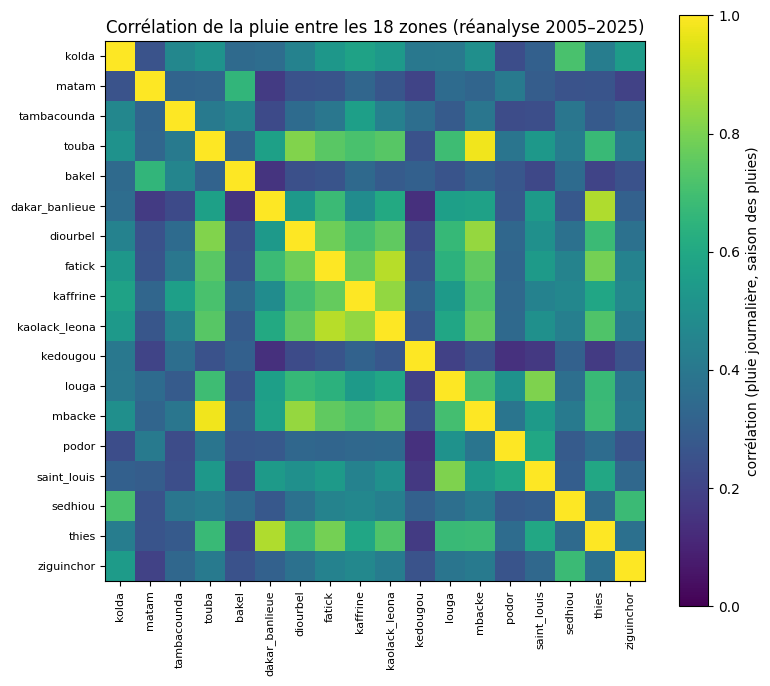

In [7]:
C_ = REA_P[season].corr()
pairs = (C_.where(np.triu(np.ones(C_.shape, bool), 1)).stack().sort_values(ascending=False))
display(pairs.head(8).round(3).to_frame("corr pluie journalière 2005–2025"))
print("cellules de réanalyse distinctes :", rea[["lat_rea", "lon_rea"]].drop_duplicates().shape[0], "/", len(rea))
dist = pd.DataFrame(haversine(rea.lat_rea.values[:, None], rea.lon_rea.values[:, None],
                              rea.lat_rea.values[None, :], rea.lon_rea.values[None, :]),
                    index=rea.index, columns=rea.index)
print("paire la plus proche :", dist.where(dist > 0).stack().idxmin(), f"{dist.where(dist > 0).min().min():.1f} km")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(C_, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(len(C_))); ax.set_xticklabels(C_.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(C_))); ax.set_yticklabels(C_.index, fontsize=8)
plt.colorbar(im, label="corrélation (pluie journalière, saison des pluies)")
ax.set_title("Corrélation de la pluie entre les 18 zones (réanalyse 2005–2025)")
plt.tight_layout(); plt.savefig(OUT / "correlation_zones.png", dpi=150); plt.show()

## 4. Re-téléchargement des prévisions aux coordonnées de la réanalyse

Pour que prévision et cible portent exactement sur le même point, on re-télécharge **les 18
zones** aux coordonnées de la cellule de réanalyse (même API, même période, même agrégation que
`fetch_previous_runs.py`). Les fichiers d'origine sont conservés ; les nouveaux vont dans
`donnees_previous_runs_v2/` (le téléchargement n'est fait qu'une fois, puis mis en cache).

In [8]:
PR_V2.mkdir(exist_ok=True)
URL = "https://previous-runs-api.open-meteo.com/v1/forecast"
HOURLY = ["precipitation", "precipitation_previous_day1", "precipitation_previous_day2",
          "precipitation_previous_day3"]
for z, r in rea.iterrows():
    dest = PR_V2 / f"{z}_prevruns.csv"
    if dest.exists():
        continue
    params = dict(latitude=r.lat_rea, longitude=r.lon_rea, start_date="2024-01-01",
                  end_date="2025-07-31", hourly=",".join(HOURLY), timezone="GMT")
    for attempt in range(4):
        try:
            resp = requests.get(URL, params=params, timeout=90); resp.raise_for_status()
            h = pd.DataFrame(resp.json()["hourly"])
            h["date"] = pd.to_datetime(h["time"]).dt.floor("D")
            d = h.groupby("date").agg(actual=("precipitation", "sum"),
                                      fc_lead1=("precipitation_previous_day1", "sum"),
                                      fc_lead2=("precipitation_previous_day2", "sum"),
                                      fc_lead3=("precipitation_previous_day3", "sum")).reset_index()
            d["location"] = z
            d["lat_demandée"], d["lon_demandée"] = r.lat_rea, r.lon_rea
            d.to_csv(dest, index=False)
            print(f"✓ {z:15s} {len(d)} jours")
            break
        except Exception as e:
            print(f"  {z}: tentative {attempt+1} échouée ({e})"); time.sleep(5)
    time.sleep(1)
print(len(list(PR_V2.glob('*_prevruns.csv'))), "fichiers dans", PR_V2.name)

18 fichiers dans donnees_previous_runs_v2


In [9]:
m2 = match_table(PR_V2)
m2.to_csv(OUT / "correspondance_pluie_prevruns_v2.csv")
comp = m1[["corr_même_zone", "verdict"]].join(m2[["corr_même_zone", "verdict"]], lsuffix=" (v1)", rsuffix=" (v2)")
comp

,corr_même_zone (v1),verdict (v1),corr_même_zone (v2),verdict (v2)
fichier,,,,
bakel,1.0,ok,1.0,ok
dakar_banlieue,1.0,ok,1.0,ok
diourbel,1.0,ok,1.0,ok
fatick,1.0,ok,1.0,ok
kaffrine,1.0,ok,1.0,ok
kaolack_leona,1.0,ok,1.0,ok
kedougou,1.0,ok,1.0,ok
kolda,1.0,ok,1.0,ok
louga,1.0,ok,1.0,ok


In [10]:
# Différence entre anciens et nouveaux fichiers, zone par zone (prévision J+1)
diffs = []
for z in rea.index:
    a = pd.read_csv(PR_DIR / f"{z}_prevruns.csv", parse_dates=["date"]).set_index("date")
    b = pd.read_csv(PR_V2 / f"{z}_prevruns.csv", parse_dates=["date"]).set_index("date")
    j = a[["fc_lead1"]].join(b[["fc_lead1"]], lsuffix="_v1", rsuffix="_v2").dropna()
    diffs.append(dict(zone=z, corr_v1_v2=j.corr().iloc[0, 1], ecart_moyen_mm=(j.fc_lead1_v1 - j.fc_lead1_v2).abs().mean()))
diffs = pd.DataFrame(diffs).set_index("zone").round(3)
diffs.sort_values("corr_v1_v2")

,corr_v1_v2,ecart_moyen_mm
zone,,
fatick,0.896,0.292
kaolack_leona,0.934,0.319
louga,0.952,0.175
sedhiou,0.963,0.497
ziguinchor,0.971,0.457
kedougou,0.976,0.589
tambacounda,1.000,0.000
kolda,1.000,0.000
diourbel,1.000,0.000


## 5. Conclusions

*(exécution du 24/09/2026)*

**1. Les 18 zones sont bien réelles et bien placées.** Chaque cellule de réanalyse est à
1–7 km du centre de sa ville (géocodage filtré par région), les 18 cellules sont distinctes.
Les 18 fichiers de prévision présents sur disque correspondent exactement à leur zone
(corrélation de la pluie = 1,0 avec leur propre zone). La contre-épreuve montre que le test est
discriminant : aux anciennes coordonnées erronées, la corrélation tomberait à 0,74–0,75 et la
série ressemblerait à Louga ou Kaffrine.

**2. Mais les scripts sont obsolètes (risque de reproductibilité).** `fetch_previous_runs.py`
contient encore les coordonnées **erronées** de Keur Massar (15,431 ; −15,887 → à 169 km, dans la
région de Louga) et de Kaolack (13,814 ; −15,551 → à 68 km). Relancer ce script (comme l'annonce
la section *Data and Code Availability*) ré-introduirait l'erreur. De plus, le fichier de la
banlieue de Dakar porte l'étiquette `keur_massar`, ce qui l'excluait de l'expérience §V-B.

**3. Origine probable de l'erreur initiale : un homonyme.** Il existe au moins trois
« Keur Massar » au Sénégal (régions de Dakar, Louga et Kaffrine) ; l'ancienne coordonnée est
exactement celui de Louga. Détail utile pour l'article (§III-A) : la vérification par géocodage
inverse est justifiée par ce type d'homonymie.

**4. Redondance Touba–Mbacké.** Cellules distinctes mais à 10,8 km, pluie corrélée à 0,98
(la paire suivante n'est qu'à 0,89). Le critère de fusion de l'article (corr. = 1,000 pour la
banlieue de Dakar) ne les fusionne pas, mais c'est une quasi-réplication à signaler.

**5. Re-téléchargement (`donnees_previous_runs_v2/`).** Aux coordonnées exactes des cellules de
réanalyse, les prévisions changent légèrement pour 6 zones (corr. J+1 de 0,90 à 0,98 avec
l'ancienne version, car le script *extra* utilisait les coordonnées des villes). La validation
temporelle refaite avec v2 (`validation_temporelle_prevision_v2.ipynb`) donne **les mêmes
conclusions** : prévision brute AUC 0,868, historique + prévision 0,860, RF réanalyse+prévision 0,832.

**À faire :** corriger les coordonnées et les étiquettes dans `fetch_previous_runs*.py` (utiliser
les coordonnées des cellules de réanalyse), et utiliser v2 comme jeu de référence.